# sfig15 — Task Similarity Clustermap (Supplementary Fig. S-15)

Hierarchical clustermap of AUROC at each context length across all tasks.
Rows = tasks (clustered by saturation curve shape); columns = context lengths.

**Data**: `analysis.csv`, k=all, Transformer head.

In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
import sys
from pathlib import Path

# ── Workspace root ────────────────────────────────────────────────────────────
def _find_workspace():
    candidate = Path.cwd().resolve()
    for _ in range(10):
        if (candidate / "final_results").exists():
            return candidate
        if candidate.parent == candidate:
            break
        candidate = candidate.parent
    return Path("/Users/boshra/NSRR-workspace").resolve()

WORKSPACE_ROOT = _find_workspace()
NSRR_TOOLS     = WORKSPACE_ROOT / "NSRR-tools"
PAPER_FIGURES  = NSRR_TOOLS / "results" / "paper_figures"
FINAL_OUT      = PAPER_FIGURES / "final_npj"
FINAL_OUT.mkdir(parents=True, exist_ok=True)

# Main utils first (must come before explore to avoid shadowing utils.style)
_nb_dir = PAPER_FIGURES / "notebooks_npj"
sys.path.insert(0, str(_nb_dir))
# Explore panel functions — add utils/ subdir directly, not the parent package
_explore_utils = PAPER_FIGURES / "explore" / "notebooks" / "utils"
sys.path.insert(1, str(_explore_utils))

from utils.style import (
    apply_tbme_style, save_figure, FULL_W, HALF_W,
    MAIN_TASKS, SUPP_TASKS, ALL_TASKS,
    TASK_LABEL, FONT_BASE, FONT_ANNOT, FONT_LABEL, FONT_TITLE, CTX_ORDER,
    HEAD_STYLE,
)
from utils.data import set_root, load_analysis, load_heatmap, load_parquets
from utils import panels
import panels_explore as xp   # from explore utils dir, no package conflict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

set_root(WORKSPACE_ROOT)
apply_tbme_style()

_ok = (WORKSPACE_ROOT / "final_results").exists()
print(f"WORKSPACE_ROOT : {WORKSPACE_ROOT}")
print(f"final_results/ : {'✓ found' if _ok else '✗ NOT FOUND — edit _find_workspace() fallback'}")

WORKSPACE_ROOT : /Users/boshra/NSRR-workspace
final_results/ : ✓ found


In [3]:
# ── Config ────────────────────────────────────────────────────────────────────
TASKS = MAIN_TASKS #+ ["depression_extreme_binary", "osa_binary_apples_postqc"]
HEAD  = "transformer"

df = load_analysis("phase0_v3", split="test", k="all")
print("Tasks in analysis.csv:", sorted(df["task"].unique()))

Tasks in analysis.csv: ['age_class', 'apnea_binary', 'bmi_binary', 'depression_extreme_binary', 'osa_binary_apples_postqc', 'sex_binary', 'sleep_efficiency_binary']


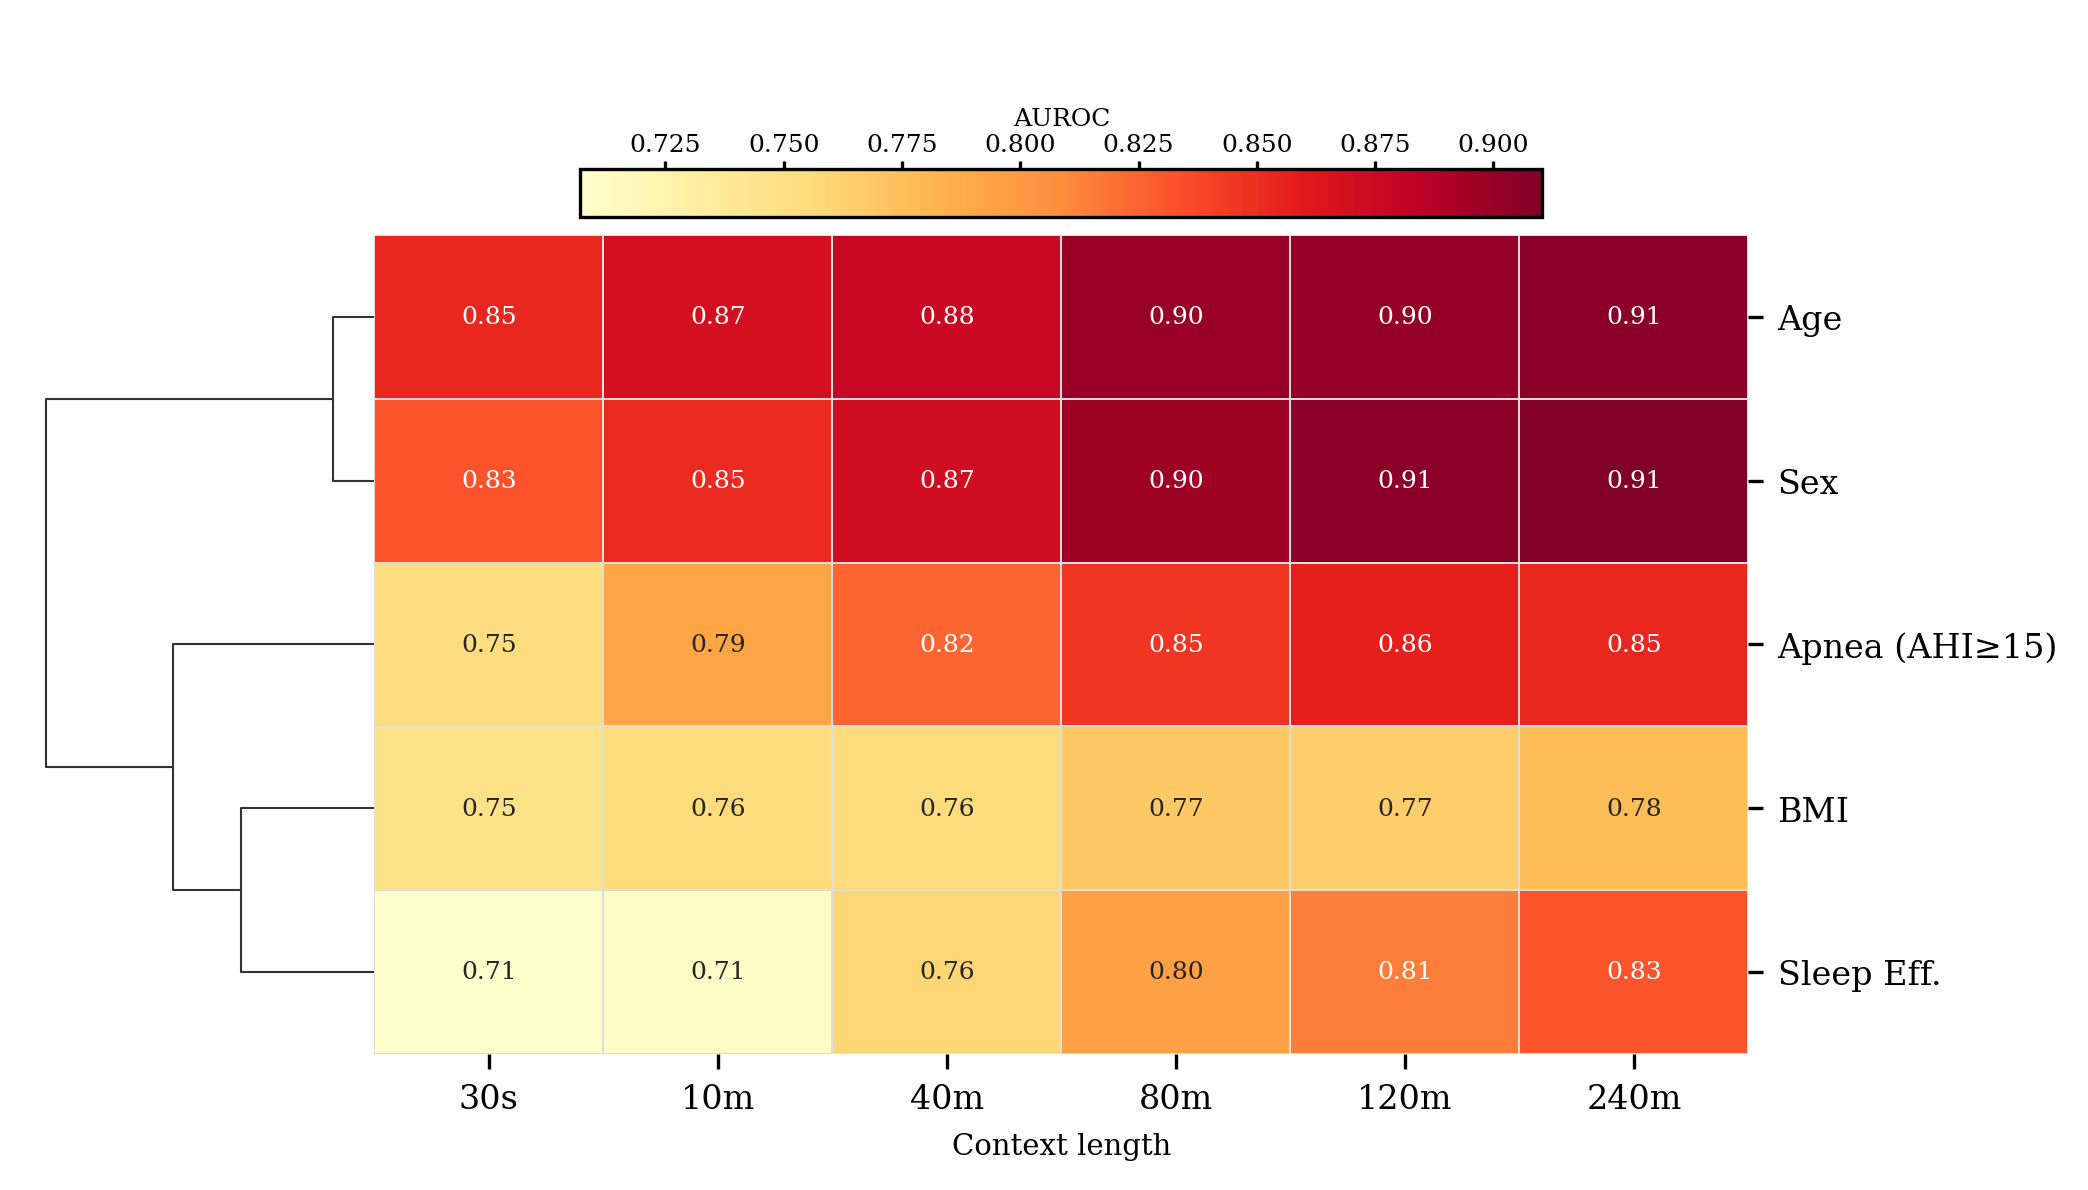

In [4]:
g = xp.task_clustermap(
    df,
    tasks=TASKS,
    head=HEAD,
    figsize=(7.0, 4.0),
    # cbar on right side, no title
)
plt.show()

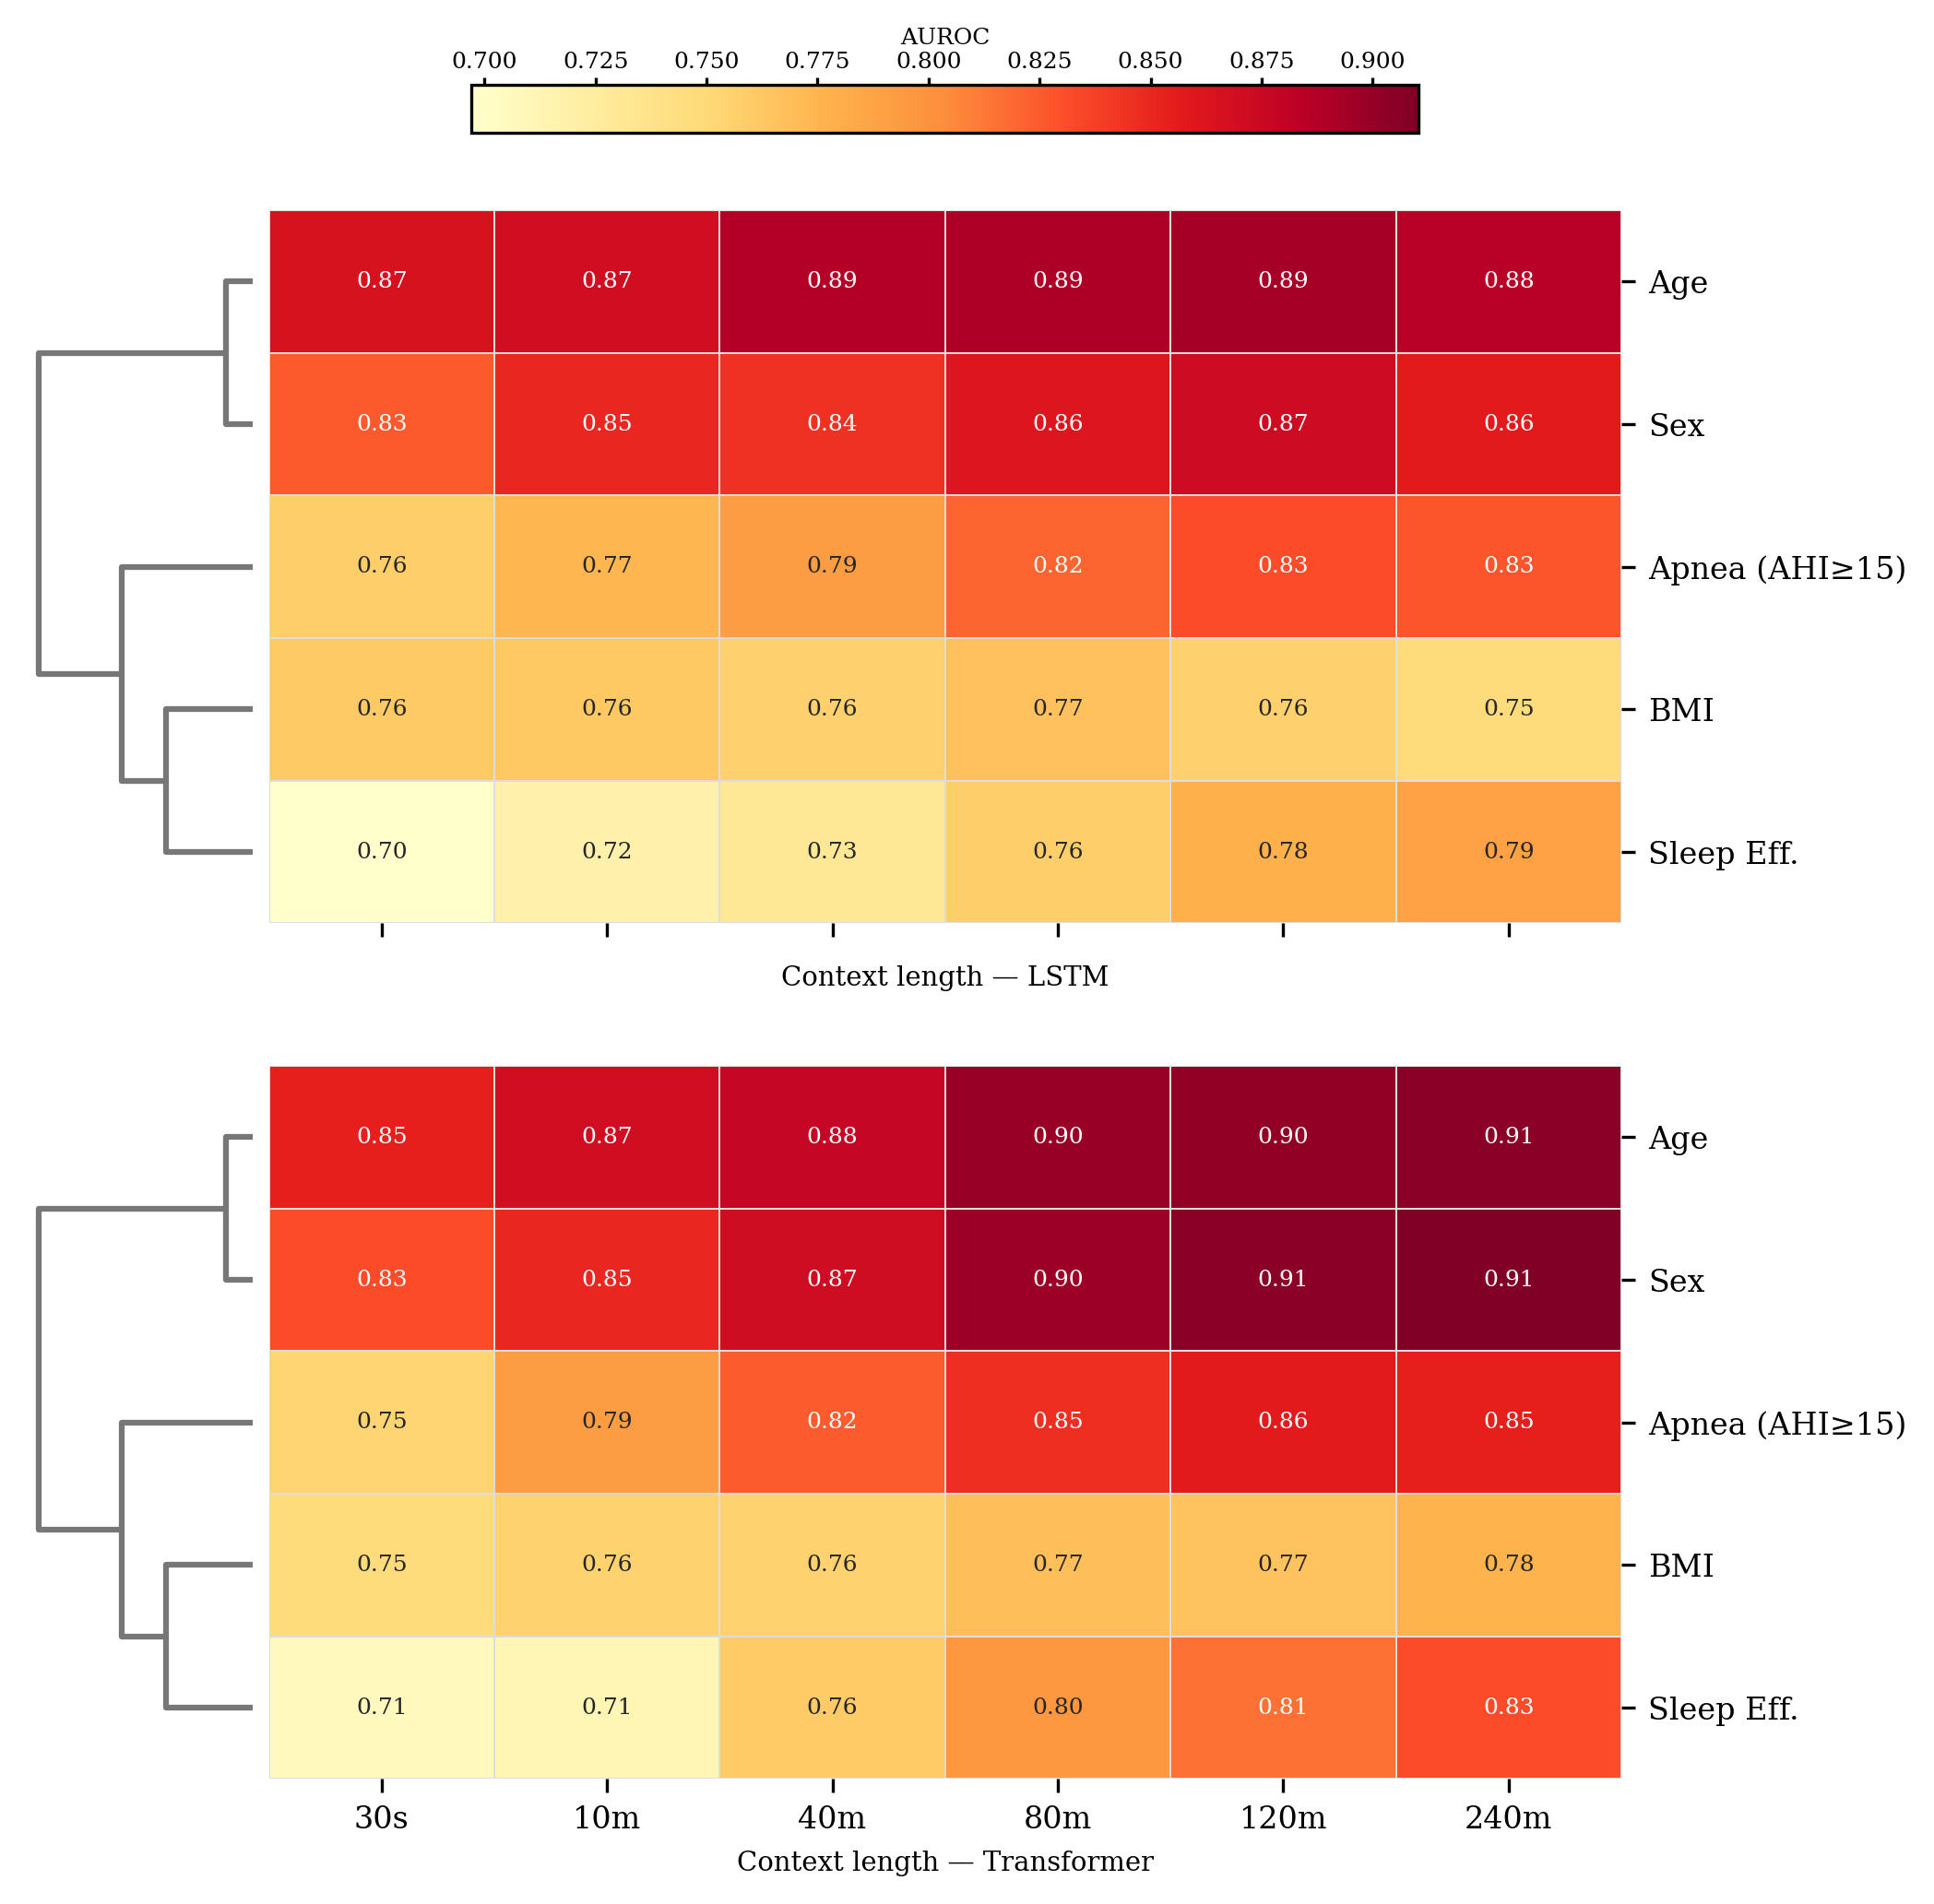

  saved → /Users/boshra/NSRR-workspace/NSRR-tools/results/paper_figures/final/sfig11_task_clustermap.pdf
Saved + copied → TBME_submission/sfig11_task_clustermap.pdf


In [ ]:
# ── BOTH HEADS stacked 2×1 (uncomment to use instead of single-head above) ────
# Layout: [dendrogram(narrow) | heatmap(wide)] × 2 rows, LSTM on top.
# Rows sorted by transformer clustering so both panels share the same tree.
# Head names on x-axis (no panel titles). Horizontal colorbar above.
# vmin/vmax from actual data → identical colour scale as the single-head figure.
#
import seaborn as sns
from scipy.cluster.hierarchy import linkage, dendrogram, leaves_list
from scipy.spatial.distance import pdist
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from utils.style import CONTEXT_TO_MIN, MIN_TO_CTX
import numpy as np

def _make_pivot(head):
    sub = df[(df["head"] == head) & df["mean_prob_auroc"].notna()]
    piv = (sub[sub["task"].isin(TASKS)]
           .pivot_table(index="task", columns="context_length_min",
                        values="mean_prob_auroc", aggfunc="mean")
           .reindex(columns=sorted(CONTEXT_TO_MIN.values())))
    piv.columns = [MIN_TO_CTX.get(c, f"{c}m") for c in piv.columns]
    piv.index   = [TASK_LABEL.get(t, t) for t in piv.index]
    return piv.dropna(how="all").fillna(piv.mean())

_piv_tr = _make_pivot("transformer")
_piv_ls = _make_pivot("lstm")
_link   = linkage(pdist(_piv_tr.values), method="average", metric="euclidean")
_order  = leaves_list(_link)
_n      = len(_order)

VMIN = float(min(_piv_tr.min().min(), _piv_ls.min().min()))
VMAX = float(max(_piv_tr.max().max(), _piv_ls.max().max()))

# 2 rows × 2 cols: narrow dendrogram col + wide heatmap col
# hspace: vertical gap between rows as fraction of average axes height —
#   raise this value to push the lower panel down and reveal the upper xlabel
_fig = plt.figure(figsize=(FULL_W - 1, 7.0))
_gs  = _fig.add_gridspec(
    2, 2,
    width_ratios=[1, 6], height_ratios=[1, 1],
    hspace=0.20, wspace=0.02,
    top=0.86, bottom=0.05, left=0.02, right=0.98,
)
_ax_dend_0 = _fig.add_subplot(_gs[0, 0])
_ax_dend_1 = _fig.add_subplot(_gs[1, 0])
_ax_l      = _fig.add_subplot(_gs[0, 1])   # LSTM
_ax_t      = _fig.add_subplot(_gs[1, 1])   # Transformer

for _ax, _head, _piv_base, _show_xticks in [
    (_ax_l, "lstm",        _piv_ls, False),
    (_ax_t, "transformer", _piv_tr, True),
]:
    sns.heatmap(_piv_base.iloc[_order], ax=_ax,
                cmap="YlOrRd", annot=True, fmt=".2f",
                annot_kws={"size": FONT_ANNOT}, linewidths=0.4,
                linecolor="#dddddd", vmin=VMIN, vmax=VMAX, cbar=False)
    _ax.yaxis.tick_right()
    _ax.set_yticklabels(_ax.get_yticklabels(), rotation=0, fontsize=FONT_BASE)
    _ax.set_xlabel(f"Context length — {HEAD_STYLE[_head]['label']}", fontsize=FONT_LABEL)
    _ax.set_ylabel("")
    _ax.tick_params(axis="x", labelsize=FONT_BASE)
    if not _show_xticks:
        _ax.set_xticklabels([])

# Dendrograms — same tree for both rows, y-axis inverted to match heatmap
# scipy places leaf i at y = (2i+1)*5; ylim=(n*10, 0) aligns top-to-bottom
for _ax_dend in [_ax_dend_0, _ax_dend_1]:
    dendrogram(_link, ax=_ax_dend, orientation='left', no_labels=True,
               color_threshold=0, link_color_func=lambda k: '#777777')
    _ax_dend.set_ylim(_n * 10, 0)
    _ax_dend.axis('off')

# Resolve layout so get_position() returns the real coordinates
_fig.canvas.draw()

# Horizontal colorbar centred over the heatmap column (not the full figure)
_hm_p    = _ax_l.get_position()   # both heatmap axes share the same x extent
_cbar_w  = _hm_p.width * 0.7
_cbar_ax = _fig.add_axes([
    _hm_p.x0 + (_hm_p.width - _cbar_w) / 2,
    0.90, _cbar_w, 0.025,
])
_sm = ScalarMappable(cmap="YlOrRd", norm=Normalize(vmin=VMIN, vmax=VMAX))
_fig.colorbar(_sm, cax=_cbar_ax, orientation='horizontal')
_cbar_ax.xaxis.set_label_position('top')
_cbar_ax.xaxis.tick_top()
_cbar_ax.set_xlabel("AUROC", fontsize=FONT_ANNOT, labelpad=2)
_cbar_ax.tick_params(labelsize=FONT_ANNOT, length=2, pad=1)

plt.show()
save_figure(_fig, FINAL_OUT, "sfig15_task_clustermap")
import shutil
shutil.copy(FINAL_OUT / "sfig15_task_clustermap.pdf",
            WORKSPACE_ROOT / "npj_digital_medicine_submission" / "sfig15_task_clustermap.pdf")
print("Saved + copied → npj_digital_medicine_submission/sfig15_task_clustermap.pdf")

In [8]:
# ── Run when figure looks good ────────────────────────────────────────────────
# save_figure(g.fig, FINAL_OUT, "sfig13_task_clustermap")
# import shutil
# shutil.copy(FINAL_OUT / "sfig13_task_clustermap.pdf",
#             WORKSPACE_ROOT / "npj_digital_medicine_submission" / "sfig13_task_clustermap.pdf")
# print("Saved + copied → npj_digital_medicine_submission/sfig13_task_clustermap.pdf")

  saved → /Users/boshra/NSRR-workspace/NSRR-tools/results/paper_figures/final/sfig11_task_clustermap.pdf
Saved + copied → TBME_submission/sfig11_task_clustermap.pdf
